# Handwritten Digits — CSCI 580

Train an MLP on MNIST and evaluate on a custom set of class-collected handwritten digits.
A unified preprocessor (threshold → crop to digit → scale → center-pad) makes both
distributions look the same to the model.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm


In [ ]:
# Globals
SEED        = 42
IMG_SIZE    = 28
NUM_CLASSES = 10
N_VAL       = 5000
BATCH_TRAIN = 64
BATCH_EVAL  = 128

DATA_PATH  = str(Path.home() / 'Documents/dev/school/Handwritten-Digits-Spring-2026/digits')
MNIST_ROOT = str(Path.home() / '.cache/mnist')


## Data

In [12]:
IMG_EXTS = {'.png', '.jpg', '.jpeg'}


class HandwrittenDigits(Dataset):
    """Class-collected digits laid out as <label>-<id>.png in DATA_PATH."""
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.samples = [
            (p, int(p.stem.split('-')[0]))
            for p in self.data_dir.iterdir()
            if p.suffix.lower() in IMG_EXTS
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label


class TransformSubset(Dataset):
    """Wrap a Subset and apply a transform at __getitem__ time.

    Lets train/val splits of the same MNIST download use different transforms
    (augmented vs eval), avoiding a second download/load.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


class CenterCropToContent:
    """Threshold-binarize, crop to digit bbox, scale-preserving resize, center-pad to size.

    Auto-inverts dark-on-light images so the digit is always bright on dark bg
    (matching MNIST). Applied uniformly to MNIST and custom data so both
    distributions look the same to the model.
    """
    def __init__(self, size=IMG_SIZE, threshold=0.3, margin=2):
        self.size = size
        self.threshold = threshold
        self.margin = margin

    def __call__(self, img):
        arr = np.asarray(img.convert('L'), dtype=np.float32) / 255.0
        if arr.mean() > 0.5:        # dark digit on light bg → invert
            arr = 1.0 - arr
        mask = arr > self.threshold
        if not mask.any():
            return Image.fromarray(np.zeros((self.size, self.size), dtype=np.uint8))
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max() + 1
        x0, x1 = xs.min(), xs.max() + 1
        digit = (arr[y0:y1, x0:x1] * 255).astype(np.uint8)
        h, w = digit.shape
        target = self.size - 2 * self.margin
        scale = target / max(h, w)
        new_h, new_w = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
        digit_img = Image.fromarray(digit).resize((new_w, new_h), Image.BILINEAR)
        canvas = Image.new('L', (self.size, self.size), 0)
        canvas.paste(digit_img, ((self.size - new_w) // 2, (self.size - new_h) // 2))
        return canvas


In [13]:
# Load MNIST once with no transform; apply train/eval transforms after the split
# via TransformSubset. Avoids the double-download workaround.
mnist_train_transform = transforms.Compose([
    CenterCropToContent(IMG_SIZE),
    transforms.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.85, 1.15), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), value=0),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_eval_transform = transforms.Compose([
    CenterCropToContent(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_full = datasets.MNIST(root=MNIST_ROOT, train=True,  download=True, transform=None)
mnist_test = datasets.MNIST(root=MNIST_ROOT, train=False, download=True,
                            transform=mnist_eval_transform)

torch.manual_seed(SEED)
n_train = len(mnist_full) - N_VAL
train_subset, val_subset = random_split(mnist_full, [n_train, N_VAL])

train_set = TransformSubset(train_subset, mnist_train_transform)
val_set   = TransformSubset(val_subset,   mnist_eval_transform)

# num_workers=0: CenterCropToContent is defined in this notebook, and macOS
# spawn-mode multiprocessing can't re-import classes from __main__.
train_loader      = DataLoader(train_set, batch_size=BATCH_TRAIN, shuffle=True, num_workers=0)
val_loader        = DataLoader(val_set,   batch_size=BATCH_EVAL,                 num_workers=0)
mnist_test_loader = DataLoader(mnist_test, batch_size=BATCH_EVAL,                num_workers=0)


In [14]:
custom_transform = transforms.Compose([
    CenterCropToContent(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

custom_dataset = HandwrittenDigits(DATA_PATH, transform=custom_transform)
custom_loader  = DataLoader(custom_dataset, batch_size=BATCH_TRAIN)
print(f"Custom dataset: {len(custom_dataset)} samples")


Custom dataset: 280 samples


## Model & Training

In [ ]:
class DigitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_SIZE * IMG_SIZE, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        return self.net(x.flatten(1))


In [16]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def train_model(train_loader, val_loader, device, criterion, lr, epochs, seed=SEED):
    torch.manual_seed(seed)
    model = DigitMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for _ in tqdm(range(epochs), desc='Epoch'):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
    return model, history


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


## Train

In [17]:
def pick_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


LR = 1e-3
EPOCHS = 10

device = pick_device()
criterion = nn.CrossEntropyLoss()
print(f'Using device: {device}')

model, history = train_model(train_loader, val_loader, device, criterion,
                             lr=LR, epochs=EPOCHS)

_, mnist_test_acc = evaluate(model, mnist_test_loader, criterion, device)
_, custom_acc     = evaluate(model, custom_loader,     criterion, device)
print(f'MNIST test accuracy:  {mnist_test_acc:.3f}')
print(f'Custom data accuracy: {custom_acc:.3f}')


Using device: mps


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

MNIST test accuracy:  0.981
Custom data accuracy: 0.896


## Results

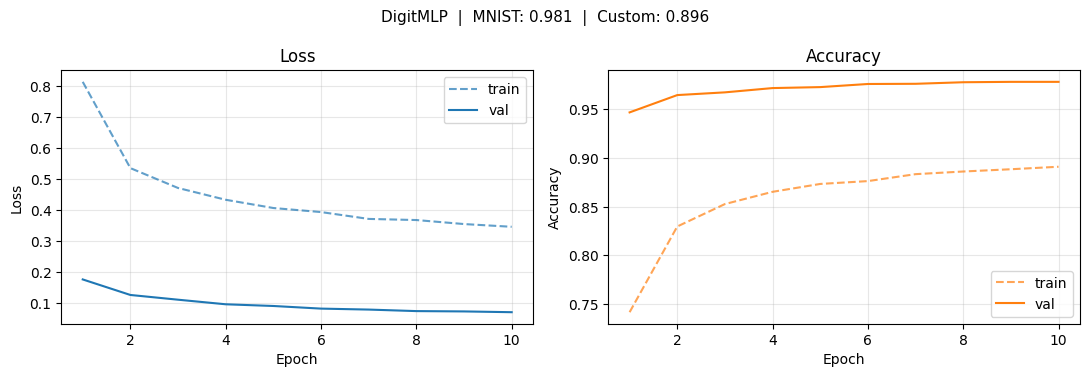

In [18]:
epochs_x = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
fig.suptitle(
    f"DigitMLP  |  MNIST: {mnist_test_acc:.3f}  |  Custom: {custom_acc:.3f}",
    fontsize=11,
)

axes[0].plot(epochs_x, history['train_loss'], '--', label='train', color='tab:blue', alpha=0.7)
axes[0].plot(epochs_x, history['val_loss'],   '-',  label='val',   color='tab:blue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(epochs_x, history['train_acc'], '--', label='train', color='tab:orange', alpha=0.7)
axes[1].plot(epochs_x, history['val_acc'],   '-',  label='val',   color='tab:orange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()


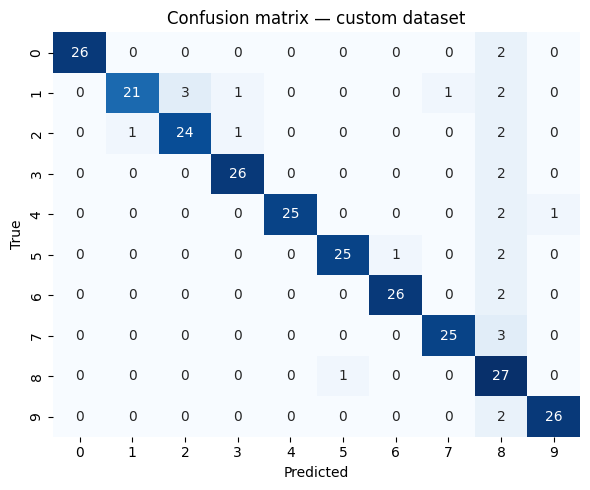

In [19]:
y_true, y_pred = get_predictions(model, custom_loader, device)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
            cbar=False, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix — custom dataset')
plt.tight_layout()
plt.show()
